In [2]:
import pandas as pd

order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

df = order_items.merge(products, on='product_id')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,5.0


In [3]:
print(df.shape)
df.isnull().sum()

(113314, 17)


order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1612
product_name_lenght              1612
product_description_lenght       1612
product_photos_qty               1612
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1636
review_score                      942
dtype: int64

In [4]:
category_summary = df.groupby('product_category_name_english').agg(
    avg_price=('price', 'mean'),
    num_orders=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

# Only keep categories with enough data to be meaningful
category_summary = category_summary[category_summary['num_orders'] > 100]
category_summary = category_summary.sort_values('num_orders', ascending=False)
category_summary.head(20)


,product_category_name_english,avg_price,num_orders,avg_review_score,avg_freight
7,bed_bath_table,93.250808,11270,3.895663,18.389787
43,health_beauty,129.859005,9727,4.142768,18.863323
65,sports_leisure,114.213392,8700,4.107986,19.502698
39,furniture_decor,87.496431,8415,3.903493,20.724965
15,computers_accessories,116.498675,7894,3.930819,18.802881
49,housewares,90.791615,6989,4.055019,20.979744
70,watches_gifts,200.979058,6001,4.019160,16.778215
68,telephony,71.173495,4550,3.946867,15.681666
42,garden_tools,111.541493,4361,4.042735,22.750307
5,auto,139.652984,4256,4.065512,21.854109


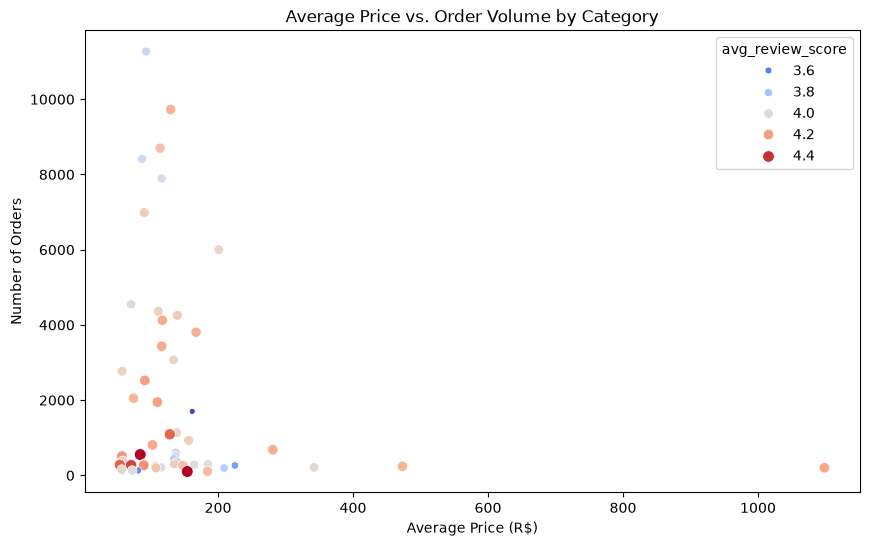

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=category_summary, x='avg_price', y='num_orders', size='avg_review_score', hue='avg_review_score', palette='coolwarm')
plt.title('Average Price vs. Order Volume by Category')
plt.xlabel('Average Price (R$)')
plt.ylabel('Number of Orders')
plt.show()

Observation: There's a general trend where lower-priced categories have higher order 
volume. A few categories (like home_appliances_2, priced ~R$473) sit at high price 
points but only have modest demand (240 orders), fitting the expected pattern rather 
than breaking it. The next step is to find categories that deviate from this trend — 
either high demand despite high price, or low demand despite low price — using a 
calculated opportunity score rather than eyeballing the chart..

In [6]:
category_summary[(category_summary['avg_price'] > 350) & (category_summary['avg_price'] < 500)]

,product_category_name_english,avg_price,num_orders,avg_review_score,avg_freight
45,home_appliances_2,473.272458,240,4.142857,44.312458


In [7]:
# Rank each category on price, demand, and review score (0 to 1 scale)
category_summary['price_rank'] = category_summary['avg_price'].rank(pct=True)
category_summary['demand_rank'] = category_summary['num_orders'].rank(pct=True)
category_summary['review_rank'] = category_summary['avg_review_score'].rank(pct=True)

# Opportunity score: high demand + high review score + relatively low price = room to raise prices
category_summary['pricing_opportunity_score'] = (
    category_summary['demand_rank'] * 0.4 +
    category_summary['review_rank'] * 0.4 -
    category_summary['price_rank'] * 0.2
)

category_summary.sort_values('pricing_opportunity_score', ascending=False).head(10)

,product_category_name_english,avg_price,num_orders,avg_review_score,avg_freight,price_rank,demand_rank,review_rank,pricing_opportunity_score
66,stationery,91.604044,2525,4.193857,18.583739,0.301887,0.716981,0.867925,0.573585
8,books_general_interest,84.732152,553,4.446266,16.628427,0.207547,0.509434,1.000000,0.562264
65,sports_leisure,114.213392,8700,4.107986,19.502698,0.433962,0.962264,0.622642,0.547170
43,health_beauty,129.859005,9727,4.142768,18.863323,0.547170,0.981132,0.660377,0.547170
36,food,57.634137,510,4.218182,14.256922,0.056604,0.490566,0.886792,0.539623
69,toys,117.519976,4125,4.158641,18.797738,0.509434,0.811321,0.773585,0.532075
60,pet_shop,110.103340,1949,4.185147,20.317794,0.396226,0.679245,0.849057,0.532075
59,perfumery,116.510317,3435,4.161941,15.851994,0.490566,0.773585,0.792453,0.528302
49,housewares,90.791615,6989,4.055019,20.979744,0.264151,0.905660,0.547170,0.528302
28,fashion_bags_accessories,74.954585,2050,4.144679,15.502107,0.169811,0.698113,0.698113,0.524528


In [8]:
category_summary.sort_values('pricing_opportunity_score', ascending=True).head(10)

,product_category_name_english,avg_price,num_orders,avg_review_score,avg_freight,price_rank,demand_rank,review_rank,pricing_opportunity_score
19,construction_tools_safety,208.992371,194,3.844560,20.201546,0.886792,0.113208,0.113208,-0.086792
34,fixed_telephony,224.992415,265,3.683206,17.579660,0.905660,0.254717,0.056604,-0.056604
30,fashion_male_clothing,81.801667,132,3.641221,16.306136,0.188679,0.075472,0.037736,0.007547
0,agro_industry_and_commerce,342.124858,212,4.000000,27.564151,0.962264,0.188679,0.320755,0.011321
4,audio,139.009315,365,3.825485,15.683671,0.679245,0.415094,0.075472,0.060377
2,art,115.802105,209,3.937198,19.354880,0.452830,0.169811,0.207547,0.060377
51,kitchen_dining_laundry_garden_furniture,164.742447,282,3.964286,42.856348,0.792453,0.339623,0.264151,0.083019
1,air_conditioning,185.269226,297,3.969178,22.724680,0.849057,0.358491,0.283019,0.086792
47,home_confort,134.619542,437,3.829885,19.568581,0.584906,0.452830,0.094340,0.101887
38,furniture_bedroom,184.352545,110,4.118182,42.679273,0.830189,0.037736,0.641509,0.105660


In [ ]:
category_summary.to_csv('../dashboard/category_summary.csv', index=False)
print("Saved successfully")

Saved successfully
